<a href="https://colab.research.google.com/github/mmierzwa2002/SI_lab/blob/main/lab5/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [302]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam, AdamW
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber, LogCosh

In [303]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IBM Stock Price')
  plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

In [304]:
def return_rmse(test,predicted):
  rmse = math.sqrt(mean_squared_error(test,predicted))
  print("-"*30)
  print("Błąd średniokwadratowy modelu {:.2f}".format(rmse))
  print("-"*30)

def return_mae(test,predicted):
  mae = mean_absolute_error(test,predicted)
  mape = mean_absolute_percentage_error(test,predicted) * 100
  print("Średni błąd względny: {:.2f}.".format(mae))
  print("Średni błąd względny procentowy: {:.2f}%".format(mape))
  print("-" * 30)


In [305]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [306]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

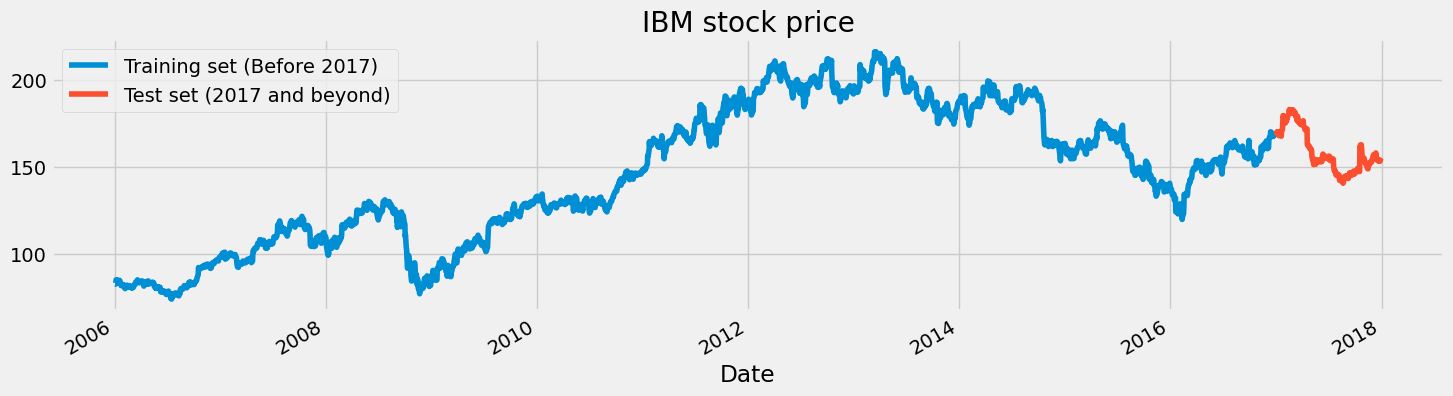

In [307]:
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017'].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [308]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [309]:
X_train = []
y_train = []
for i in range(60, 2769):
  X_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [310]:
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

In [311]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='Huber')

regressor.fit(X_train, y_train, epochs=50, batch_size=32)

#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#regressor.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0111
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0051
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0026
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0022
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0020
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0018
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016
Epoc

In [312]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [313]:
X_test = []
for i in range(60, 311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


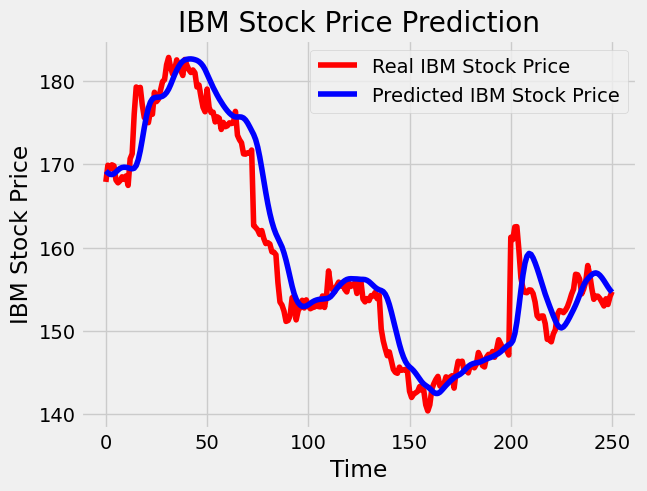

In [314]:
plot_predictions(test_set,predicted_stock_price)

In [315]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.48
------------------------------
Średni błąd względny: 2.45.
Średni błąd względny procentowy: 1.54%
------------------------------


In [316]:
regressorGRU = Sequential()
regressorGRU.add(Input(shape = (X_train.shape[1], 1)))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='adam', loss='Huber')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0051 - val_loss: 2.4394e-04
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0014 - val_loss: 4.9069e-04
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0011 - val_loss: 8.7124e-04
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0014 - val_loss: 2.7808e-04
Epoch 5/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.1270e-04 - val_loss: 1.9778e-04
Epoch 6/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 9.8369e-04 - val_loss: 3.2928e-04
Epoch 7/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0010 - val_loss: 1.9619e-04
Epoch 8/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.6414e-04 - val_loss: 1.6396e-04
Epoch 9/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 9.3043e-04 - val_loss: 4.5758e-04
Epoch 10/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.6188e-04 - val_loss: 3.8972e-04
Epoch 11/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - lo

In [317]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


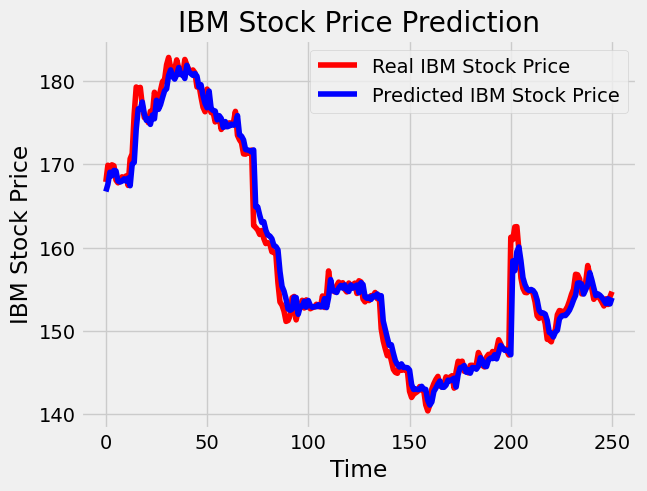

In [318]:
plot_predictions(test_set,GRU_predicted_stock_price)

In [319]:
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 1.74
------------------------------
Średni błąd względny: 1.09.
Średni błąd względny procentowy: 0.68%
------------------------------
